<a href="https://colab.research.google.com/github/manuflog/contextuality-obstructions/blob/main/ks_loop_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# The Kochen–Specker loop on IBM Quantum: witness invariance $\sum_j \langle P_j\rangle = 11$ and the holonomy eigenphase

**What this notebook does.** It runs, on an IBM Quantum simulator and (optionally) real IBM
Quantum hardware, an experimental test of two exact mathematical facts about the Peres–Penrose
33-ray Kochen–Specker (KS) set in $d=3$, established in:

> M. Flores Gordillo, *Exact rigidity certificates for Kochen–Specker sets, the graded flex
> dictionary, and the Peres–Penrose circle*, Preprints.org 224406 (2026).

The Gould–Aravind "SLICE" construction (Gould & Aravind, *Found. Phys.* **40**, 1096 (2010),
arXiv:0909.4502, Table 3) gives a **one-parameter family** of 33 unit rays $v_j(\theta) \in
\mathbb{C}^3$, $\theta \in [0, 2\pi)$, with $\theta=0$ the real Peres-33 configuration and
$\theta = \pi/2$ the essentially-complex Penrose-33 configuration — the *same* Kochen–Specker
orthogonality graph (16 triads + 24 orthogonal dyads, 72 edges) holds identically in $\theta$.

**Experiment 1 (main, always runs): witness invariance.** Let $P_j(\theta) =
v_j(\theta)v_j(\theta)^\dagger$. The paper proves *exactly* (a Laurent-polynomial identity, not a
numerical coincidence) that

$$\sum_{j=1}^{33} P_j(\theta) \;=\; 11\, I_3 \qquad \text{identically in } \theta.$$

So for **any** quantum state $|\psi\rangle$ and **any** $\theta$, $\sum_j \langle\psi|P_j(\theta)|
\psi\rangle = 11$ — even though the *individual* profiles $\langle P_j(\theta)\rangle$ change
substantially with $\theta$ (the rays rotate through the complex KS family). This is the
state-independent-contextuality "sum rule" behind the Peres/Penrose Kochen–Specker proof, made
into a continuously-tunable one-parameter family. We measure it at three canonical points,
classified by the arithmetic of the ring generated by the ray coordinates:

| name | $\theta$ | ring type |
|---|---|---|
| Peres | $0$ | $\mathbb{Q}(\sqrt2)$ (real) |
| Gaussian | $\pi/4$ | $\mathbb{Z}[i]$ |
| Penrose | $\pi/2$ | $\mathbb{Q}(\sqrt2)$ (essentially complex) |

**Experiment 2 (optional; simulator always, hardware guarded off by default): holonomy
eigenphase.** The Wilczek–Zee/Berry holonomy $W = \mathcal{P}\exp\oint A(\theta)\,d\theta$ of the
frame connection $A(\theta) = A_0 + A_1 e^{i\theta} + A_{-1}e^{-i\theta}$ (exact 3-term Fourier
series, no higher harmonics) has eigenvalues $\{1, e^{+i\phi}, e^{-i\phi}\}$ with the **exact
closed form**

$$\phi = \frac{2\pi\sqrt{1867}}{33} \pmod{2\pi}, \qquad \frac{\phi}{2\pi} \bmod 1 = 0.309357436\ldots$$

(1867 is prime, so $\phi$ is *not* a rational multiple of $2\pi$ — $W$'s nontrivial eigenvalues
are not roots of unity). We measure $\phi$ via a Hadamard test of the discretized ordered-product
holonomy $W_N = U_{N-1}\cdots U_1 U_0$.

**Predictions table (exact, float64 evaluation of exact algebraic data):**

| quantity | predicted value |
|---|---|
| $\sum_j \langle P_j(\theta)\rangle$, any state, any $\theta \in \{0,\pi/4,\pi/2\}$ | $11.000000$ |
| $\phi/2\pi \bmod 1$ (holonomy eigenphase, canonical Gould–Aravind section) | $0.309357436$ |

**Self-containment / honesty.** This notebook does **not** import from the
`contextuality-obstructions` repository. All 33 rays at the three $\theta$ values, and the
$A_0, A_1, A_{-1}$ connection matrices, are embedded below as explicit complex-number literals,
generated by actually running the repo's `peres_penrose.py` / `phi_hunt.py` machinery once
(`extract_data.py` in this same directory documents that extraction) and pasting the numbers
here. A SHA256 checksum of the embedded ray array is hardcoded and re-verified in-notebook
(Cell 3) so any transcription error is caught automatically rather than silently trusted. The
local-simulator cell (Cell 5) **must pass headlessly** — it is the notebook's own proof that the
embedded data reproduces the $\sum P_j = 11$ identity before anything is sent to real hardware.


In [ ]:
# Install pinned-ish versions of qiskit + IBM Runtime + Aer simulator (quiet).
# Safe to re-run; Colab already ships numpy/scipy/matplotlib.
%pip install -q "qiskit>=1.4,<3" "qiskit-ibm-runtime>=0.30" "qiskit-aer>=0.15"
import qiskit, qiskit_aer, qiskit_ibm_runtime
print("qiskit", qiskit.__version__, "| qiskit-aer", qiskit_aer.__version__,
      "| qiskit-ibm-runtime", qiskit_ibm_runtime.__version__)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 43.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.4/400.4 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.3/111.3 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 44.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.2/224.2 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.6/76.6 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 4.0 MB/s eta 0:00:00
qiskit 2.5.0 | qiskit-aer 0.17.2 | qiskit-ibm-runtime 0.48.0


In [ ]:
# =====================================================================================
# EMBEDDED DATA -- the 33 normalized Gould-Aravind "SLICE" qutrit rays v_j(theta)/||v_j(theta)||
# at theta in {0 (Peres), pi/4 (Gaussian), pi/2 (Penrose)}, and the exact holonomy connection
# matrices A0, A1, Am (A(theta) = A0 + A1*e^{i theta} + Am*e^{-i theta}), used only by the
# optional EXP2 cell.
#
# PROVENANCE: these numbers are NOT hand-typed or fit. They were generated by actually running
# the unmodified peres_penrose.py (rays_c(..., SLICE)) and phi_hunt.py (build_A0_A1_Am) modules
# from the contextuality-obstructions repository ONE TIME, in this same ibm_experiment/
# directory (see extract_data.py), and pasted here verbatim (17 significant digits, float64).
# The ray data underlying this evaluation is itself EXACT (entries m_jc * z^{e_jc}, z=e^{i theta},
# e_jc in {-1,0,1}, m_jc in Z[sqrt2] -- see peres_penrose.py sections [1],[4a-e]); what you see
# below is a float64 evaluation of that exact object at three theta values, not a numerical fit.
#
# INTEGRITY CHECK: EXPECTED_SHA256 below is the SHA256 of
#   np.round(np.stack([RAYS_PERES, RAYS_GAUSSIAN, RAYS_PENROSE]), 12).tobytes()
# computed once at extraction time (extract_data.py). We recompute the SAME hash from the
# literals immediately below and assert they match -- this catches any transcription/paste
# corruption automatically rather than silently trusting the pasted numbers.
# =====================================================================================
import numpy as np
import hashlib

EXPECTED_SHA256 = "5107d6b9142c4ffbba04abc66cc7488dc4c301d317ae512b3ca5f5682ef8157a"  # hardcoded at extraction time (extract_data.py)

RAYS_PERES = np.array([
    [(1.0+0.0j), (0.0+0.0j), (0.0+0.0j)],
    [(0.0+0.0j), (1.0+0.0j), (0.0+0.0j)],
    [(0.0+0.0j), (0.0+0.0j), (1.0+0.0j)],
    [(0.0+0.0j), (0.7071067811865475+0.0j), (0.7071067811865475+0.0j)],
    [(0.0+0.0j), (0.7071067811865475+0.0j), (-0.7071067811865475+0.0j)],
    [(0.7071067811865475+0.0j), (0.0+0.0j), (0.7071067811865475+0.0j)],
    [(0.7071067811865475+0.0j), (0.0+0.0j), (-0.7071067811865475+0.0j)],
    [(0.7071067811865475+0.0j), (-0.7071067811865475+0.0j), (0.0+0.0j)],
    [(-0.7071067811865475+0.0j), (-0.7071067811865475+0.0j), (0.0+0.0j)],
    [(0.7071067811865476+0.0j), (-0.5+0.0j), (0.5+0.0j)],
    [(0.7071067811865476+0.0j), (0.5+0.0j), (0.5+0.0j)],
    [(-0.7071067811865476+0.0j), (0.5+0.0j), (0.5+0.0j)],
    [(0.7071067811865476+0.0j), (0.5+0.0j), (-0.5+0.0j)],
    [(-0.5+0.0j), (0.7071067811865476+0.0j), (0.5+0.0j)],
    [(0.5+0.0j), (0.7071067811865476+0.0j), (0.5+0.0j)],
    [(0.5+0.0j), (-0.7071067811865476+0.0j), (0.5+0.0j)],
    [(0.5+0.0j), (0.7071067811865476+0.0j), (-0.5+0.0j)],
    [(0.5+0.0j), (0.5+0.0j), (0.7071067811865476+0.0j)],
    [(0.5+0.0j), (-0.5+0.0j), (-0.7071067811865476+0.0j)],
    [(0.5+0.0j), (-0.5+0.0j), (0.7071067811865476+0.0j)],
    [(-0.5+0.0j), (-0.5+0.0j), (0.7071067811865476+0.0j)],
    [(0.5773502691896257+0.0j), (0.0+0.0j), (0.816496580927726+0.0j)],
    [(0.5773502691896257+0.0j), (-0.816496580927726+0.0j), (0.0+0.0j)],
    [(0.5773502691896257+0.0j), (0.816496580927726+0.0j), (0.0+0.0j)],
    [(0.5773502691896257+0.0j), (0.0+0.0j), (-0.816496580927726+0.0j)],
    [(0.0+0.0j), (0.5773502691896257+0.0j), (0.816496580927726+0.0j)],
    [(-0.816496580927726+0.0j), (0.5773502691896257+0.0j), (0.0+0.0j)],
    [(0.816496580927726+0.0j), (0.5773502691896257+0.0j), (0.0+0.0j)],
    [(0.0+0.0j), (0.5773502691896257+0.0j), (-0.816496580927726+0.0j)],
    [(0.0+0.0j), (0.816496580927726+0.0j), (0.5773502691896257+0.0j)],
    [(0.816496580927726+0.0j), (0.0+0.0j), (0.5773502691896257+0.0j)],
    [(-0.816496580927726+0.0j), (0.0+0.0j), (0.5773502691896257+0.0j)],
    [(0.0+0.0j), (-0.816496580927726+0.0j), (0.5773502691896257+0.0j)],
], dtype=complex)

RAYS_GAUSSIAN = np.array([
    [(1.0+0.0j), (0.0+0.0j), (0.0+0.0j)],
    [(0.0+0.0j), (1.0+0.0j), (0.0+0.0j)],
    [(0.0+0.0j), (0.0+0.0j), (1.0+0.0j)],
    [(0.0+0.0j), (0.7071067811865475+0.0j), (0.5+0.4999999999999999j)],
    [(0.0+0.0j), (0.5-0.4999999999999999j), (-0.7071067811865475+0.0j)],
    [(0.7071067811865475+0.0j), (0.0+0.0j), (0.7071067811865475+0.0j)],
    [(0.7071067811865475+0.0j), (0.0+0.0j), (-0.7071067811865475+0.0j)],
    [(0.7071067811865475+0.0j), (-0.5-0.4999999999999999j), (0.0+0.0j)],
    [(-0.5+0.4999999999999999j), (-0.7071067811865475+0.0j), (0.0+0.0j)],
    [(0.5000000000000001-0.5j), (-0.3535533905932738+0.35355339059327373j), (0.5+0.0j)],
    [(0.7071067811865476+0.0j), (0.5+0.0j), (0.3535533905932738+0.35355339059327373j)],
    [(-0.7071067811865476+0.0j), (0.5+0.0j), (0.3535533905932738+0.35355339059327373j)],
    [(0.5000000000000001-0.5j), (0.3535533905932738-0.35355339059327373j), (-0.5+0.0j)],
    [(-0.5+0.0j), (0.7071067811865476+0.0j), (0.5+0.0j)],
    [(0.5+0.0j), (0.7071067811865476+0.0j), (0.5+0.0j)],
    [(0.5+0.0j), (-0.7071067811865476+0.0j), (0.5+0.0j)],
    [(0.5+0.0j), (0.7071067811865476+0.0j), (-0.5+0.0j)],
    [(0.3535533905932738-0.35355339059327373j), (0.5+0.0j), (0.7071067811865476+0.0j)],
    [(0.5+0.0j), (-0.3535533905932738-0.35355339059327373j), (-0.5000000000000001-0.5j)],
    [(0.5+0.0j), (-0.3535533905932738-0.35355339059327373j), (0.5000000000000001+0.5j)],
    [(-0.3535533905932738+0.35355339059327373j), (-0.5+0.0j), (0.7071067811865476+0.0j)],
    [(0.5773502691896257+0.0j), (0.0+0.0j), (0.5773502691896258+0.5773502691896257j)],
    [(0.5773502691896257+0.0j), (-0.816496580927726+0.0j), (0.0+0.0j)],
    [(0.5773502691896257+0.0j), (0.816496580927726+0.0j), (0.0+0.0j)],
    [(0.5773502691896257+0.0j), (0.0+0.0j), (-0.5773502691896258-0.5773502691896257j)],
    [(0.0+0.0j), (0.5773502691896257+0.0j), (0.816496580927726+0.0j)],
    [(-0.816496580927726+0.0j), (0.5773502691896257+0.0j), (0.0+0.0j)],
    [(0.816496580927726+0.0j), (0.5773502691896257+0.0j), (0.0+0.0j)],
    [(0.0+0.0j), (0.5773502691896257+0.0j), (-0.816496580927726+0.0j)],
    [(0.0+0.0j), (0.816496580927726+0.0j), (0.5773502691896257+0.0j)],
    [(0.5773502691896258-0.5773502691896257j), (0.0+0.0j), (0.5773502691896257+0.0j)],
    [(-0.5773502691896258+0.5773502691896257j), (0.0+0.0j), (0.5773502691896257+0.0j)],
    [(0.0+0.0j), (-0.816496580927726+0.0j), (0.5773502691896257+0.0j)],
], dtype=complex)

RAYS_PENROSE = np.array([
    [(1.0+0.0j), (0.0+0.0j), (0.0+0.0j)],
    [(0.0+0.0j), (1.0+0.0j), (0.0+0.0j)],
    [(0.0+0.0j), (0.0+0.0j), (1.0+0.0j)],
    [(0.0+0.0j), (0.7071067811865475+0.0j), (4.329780281177466e-17+0.7071067811865475j)],
    [(0.0+0.0j), (4.329780281177466e-17-0.7071067811865475j), (-0.7071067811865475+0.0j)],
    [(0.7071067811865475+0.0j), (0.0+0.0j), (0.7071067811865475+0.0j)],
    [(0.7071067811865475+0.0j), (0.0+0.0j), (-0.7071067811865475+0.0j)],
    [(0.7071067811865475+0.0j), (-4.329780281177466e-17-0.7071067811865475j), (0.0+0.0j)],
    [(-4.329780281177466e-17+0.7071067811865475j), (-0.7071067811865475+0.0j), (0.0+0.0j)],
    [(4.329780281177467e-17-0.7071067811865476j), (-3.061616997868383e-17+0.5j), (0.5+0.0j)],
    [(0.7071067811865476+0.0j), (0.5+0.0j), (3.061616997868383e-17+0.5j)],
    [(-0.7071067811865476+0.0j), (0.5+0.0j), (3.061616997868383e-17+0.5j)],
    [(4.329780281177467e-17-0.7071067811865476j), (3.061616997868383e-17-0.5j), (-0.5+0.0j)],
    [(-0.5+0.0j), (0.7071067811865476+0.0j), (0.5+0.0j)],
    [(0.5+0.0j), (0.7071067811865476+0.0j), (0.5+0.0j)],
    [(0.5+0.0j), (-0.7071067811865476+0.0j), (0.5+0.0j)],
    [(0.5+0.0j), (0.7071067811865476+0.0j), (-0.5+0.0j)],
    [(3.061616997868383e-17-0.5j), (0.5+0.0j), (0.7071067811865476+0.0j)],
    [(0.5+0.0j), (-3.061616997868383e-17-0.5j), (-4.329780281177467e-17-0.7071067811865476j)],
    [(0.5+0.0j), (-3.061616997868383e-17-0.5j), (4.329780281177467e-17+0.7071067811865476j)],
    [(-3.061616997868383e-17+0.5j), (-0.5+0.0j), (0.7071067811865476+0.0j)],
    [(0.5773502691896257+0.0j), (0.0+0.0j), (4.999599621739488e-17+0.816496580927726j)],
    [(0.5773502691896257+0.0j), (-0.816496580927726+0.0j), (0.0+0.0j)],
    [(0.5773502691896257+0.0j), (0.816496580927726+0.0j), (0.0+0.0j)],
    [(0.5773502691896257+0.0j), (0.0+0.0j), (-4.999599621739488e-17-0.816496580927726j)],
    [(0.0+0.0j), (0.5773502691896257+0.0j), (0.816496580927726+0.0j)],
    [(-0.816496580927726+0.0j), (0.5773502691896257+0.0j), (0.0+0.0j)],
    [(0.816496580927726+0.0j), (0.5773502691896257+0.0j), (0.0+0.0j)],
    [(0.0+0.0j), (0.5773502691896257+0.0j), (-0.816496580927726+0.0j)],
    [(0.0+0.0j), (0.816496580927726+0.0j), (0.5773502691896257+0.0j)],
    [(4.999599621739488e-17-0.816496580927726j), (0.0+0.0j), (0.5773502691896257+0.0j)],
    [(-4.999599621739488e-17+0.816496580927726j), (0.0+0.0j), (0.5773502691896257+0.0j)],
    [(0.0+0.0j), (-0.816496580927726+0.0j), (0.5773502691896257+0.0j)],
], dtype=complex)

A0 = np.array([
    [(-0.0-0.30303030303030304j), (0.0+0.0j), (0.0+0.0j)],
    [(0.0+0.0j), (0.0+0.0j), (0.0+0.0j)],
    [(0.0+0.0j), (0.0+0.0j), (0.0+0.30303030303030304j)],
], dtype=complex)

A1 = np.array([
    [(0.0+0.0j), (-0.0-0.09090909090909091j), (0.0+0.0j)],
    [(0.0+0.0j), (0.0+0.0j), (0.0+0.09090909090909091j)],
    [(0.0+0.0j), (0.0+0.0j), (0.0+0.0j)],
], dtype=complex)

Am = np.array([
    [(0.0+0.0j), (0.0+0.0j), (0.0+0.0j)],
    [(-0.0-0.09090909090909091j), (0.0+0.0j), (0.0+0.0j)],
    [(0.0+0.0j), (0.0+0.09090909090909091j), (0.0+0.0j)],
], dtype=complex)

_stacked = np.stack([RAYS_PERES, RAYS_GAUSSIAN, RAYS_PENROSE])   # shape (3, 33, 3) complex128
_rounded = np.round(_stacked, 12)
_actual_sha256 = hashlib.sha256(_rounded.tobytes()).hexdigest()
print(f"expected SHA256: {EXPECTED_SHA256}")
print(f"actual   SHA256: {_actual_sha256}")
assert _actual_sha256 == EXPECTED_SHA256, "EMBEDDED RAY DATA CORRUPTED -- checksum mismatch!"
print("CHECKSUM OK -- embedded ray data matches the extraction-time checksum.\n")

RAY_SETS = {"Peres": RAYS_PERES, "Gaussian": RAYS_GAUSSIAN, "Penrose": RAYS_PENROSE}
THETA_OF = {"Peres": 0.0, "Gaussian": np.pi / 4, "Penrose": np.pi / 2}

# sanity: all 99 rays unit norm, and the tight-frame identity sum_j |v_j><v_j| = 11*I holds
# (float64 evaluation of the exact identity, peres_penrose.py section [4e]) for all three theta
for name, rays in RAY_SETS.items():
    norms = np.linalg.norm(rays, axis=1)
    assert np.allclose(norms, 1.0, atol=1e-10), f"{name}: rays not unit-normalized"
    frame = sum(np.outer(v, v.conj()) for v in rays)
    dev = np.max(np.abs(frame - 11 * np.eye(3)))
    print(f"  {name} (theta={THETA_OF[name]:.4f}): sum_j |v_j><v_j| - 11*I max-abs-dev = {dev:.2e}")
    assert dev < 1e-8, f"{name}: tight-frame identity sum P_j=11I failed at float64 precision"
print("\nAll three theta points: sum_j |v_j><v_j| = 11*I to float64 precision. EMBEDDED DATA OK.")

print("\nA0 =\n", A0, "\nA1 =\n", A1, "\nAm =\n", Am)
assert np.allclose(A0 + A0.conj().T, 0, atol=1e-9), "A0 not anti-Hermitian"
assert np.allclose(A1 + Am.conj().T, 0, atol=1e-9), "A1 != -Am^dagger"
print("A0, A1, Am pass the anti-Hermitian / A1=-Am^dagger sanity checks.")


expected SHA256: 5107d6b9142c4ffbba04abc66cc7488dc4c301d317ae512b3ca5f5682ef8157a
actual   SHA256: 5107d6b9142c4ffbba04abc66cc7488dc4c301d317ae512b3ca5f5682ef8157a
CHECKSUM OK -- embedded ray data matches the extraction-time checksum.

  Peres (theta=0.0000): sum_j |v_j><v_j| - 11*I max-abs-dev = 3.55e-15
  Gaussian (theta=0.7854): sum_j |v_j><v_j| - 11*I max-abs-dev = 3.55e-15
  Penrose (theta=1.5708): sum_j |v_j><v_j| - 11*I max-abs-dev = 3.55e-15

All three theta points: sum_j |v_j><v_j| = 11*I to float64 precision. EMBEDDED DATA OK.

A0 =
 [[-0.-0.3030303j  0.+0.j         0.+0.j       ]
 [ 0.+0.j         0.+0.j         0.+0.j       ]
 [ 0.+0.j         0.+0.j         0.+0.3030303j]] 
A1 =
 [[ 0.+0.j         -0.-0.09090909j  0.+0.j        ]
 [ 0.+0.j          0.+0.j          0.+0.09090909j]
 [ 0.+0.j          0.+0.j          0.+0.j        ]] 
Am =
 [[ 0.+0.j          0.+0.j          0.+0.j        ]
 [-0.-0.09090909j  0.+0.j          0.+0.j        ]
 [ 0.+0.j          0.+0.09090909j  

In [ ]:
# =====================================================================================
# CIRCUIT BUILDERS -- ported from the repo's make_circuits.py (self-contained, no import).
# Encoding: a qutrit on 2 physical qubits, |00>=level0, |01>=level1, |10>=level2 (|11> unused /
# leakage-monitored). All 3x3 unitaries are embedded as block_diag(U3, 1) (identity on the
# unused |11> leakage subspace) -- see embed_4() below.
# =====================================================================================
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import UnitaryGate

BASIS_GATES = ["rz", "sx", "x", "cx"]


def complete_unitary(v):
    """Deterministic Gram-Schmidt completion of a unit vector v (C^3) to a 3x3 unitary U with
    U[:,0] == v exactly. Columns 1,2 complete the basis by Gram-Schmidt against e0,e1,e2."""
    v = np.asarray(v, dtype=complex)
    v = v / np.linalg.norm(v)
    basis = [v]
    for i in range(3):
        e = np.zeros(3, dtype=complex)
        e[i] = 1.0
        for b in basis:
            e = e - np.vdot(b, e) * b
        n = np.linalg.norm(e)
        if n > 1e-8:
            basis.append(e / n)
        if len(basis) == 3:
            break
    U = np.array(basis).T
    assert np.allclose(U.conj().T @ U, np.eye(3), atol=1e-9), "completion not unitary"
    assert np.allclose(U[:, 0], v, atol=1e-9), "first column != v"
    return U


def embed_4(U3):
    """block_diag(U3, 1): acts as U3 on {|00>,|01>,|10>} and as identity on unused |11>.
    Matrix index i = i_q1*2 + i_q0 (q0 = LSB), Qiskit's own little-endian qargs convention."""
    U4 = np.eye(4, dtype=complex)
    U4[:3, :3] = U3
    return U4


def unitary_block_circuit(U4, label):
    """A 2-qubit QuantumCircuit implementing U4, transpiled to BASIS_GATES."""
    qc = QuantumCircuit(2, name=label)
    qc.append(UnitaryGate(U4, label=label), [0, 1])
    return transpile(qc, basis_gates=BASIS_GATES, optimization_level=1)


def test_states():
    """The 3 states used in EXP1: |0>, uniform |+>, and a fixed pseudorandom qutrit state."""
    zero = np.array([1, 0, 0], dtype=complex)
    plus = np.array([1, 1, 1], dtype=complex) / np.sqrt(3)
    rng = np.random.default_rng(42)
    r = rng.normal(size=3) + 1j * rng.normal(size=3)
    r = r / np.linalg.norm(r)
    return [("zero", zero), ("plus", plus), ("random_seed42", r)]


def build_exp1_circuits():
    """Returns a list of dicts, one per (theta, ray j, state) = 3*33*3 = 297 circuits:
    {label, theta_name, theta, j, state, predicted_P, circuit}.
    Each circuit: prepare |psi>, rotate so ray e_j maps to |0> (level 0 = |00>), measure both
    qubits. <P_j(theta)> is estimated as Pr(measure "00")."""
    states = test_states()
    state_prep = {}
    for sname, psi in states:
        S3 = complete_unitary(psi)
        state_prep[sname] = unitary_block_circuit(embed_4(S3), f"prep_{sname}")

    records = []
    for tname, rays in RAY_SETS.items():
        theta = THETA_OF[tname]
        for j in range(33):
            ej = rays[j]
            Uj = complete_unitary(ej)
            Rj = Uj.conj().T                      # maps e_j -> |0>
            rot_circ = unitary_block_circuit(embed_4(Rj), f"rot_{tname}_j{j + 1}")
            for sname, psi in states:
                pred = float(abs(np.vdot(ej, psi)) ** 2)
                qc = QuantumCircuit(2, 2, name=f"exp1_{tname}_j{j + 1}_{sname}")
                qc.compose(state_prep[sname], [0, 1], inplace=True)
                qc.compose(rot_circ, [0, 1], inplace=True)
                qc.measure([0, 1], [0, 1])
                qc = transpile(qc, basis_gates=BASIS_GATES, optimization_level=1)
                records.append(dict(label=f"{tname}_j{j + 1}_{sname}", theta_name=tname,
                                     theta=theta, j=j + 1, state=sname, predicted_P=pred,
                                     circuit=qc))
    return records


EXP1_RECORDS = build_exp1_circuits()
print(f"built {len(EXP1_RECORDS)} EXP1 circuits "
      f"(expect 3 theta x 33 rays x 3 states = {3 * 33 * 3})")
assert len(EXP1_RECORDS) == 297
# witness-invariance check on the PREDICTED (exact, float64) probabilities, before any
# quantum execution -- this must hold by construction (it is the theorem being tested):
for tname in RAY_SETS:
    for sname, _ in test_states():
        s = sum(r["predicted_P"] for r in EXP1_RECORDS
                if r["theta_name"] == tname and r["state"] == sname)
        assert abs(s - 11.0) < 1e-9, f"predicted sum failed for {tname}/{sname}: {s}"
print("predicted (noiseless) sum_j P_j(theta) = 11.000000 for all 3 theta x 3 states. OK.")


built 297 EXP1 circuits (expect 3 theta x 33 rays x 3 states = 297)
predicted (noiseless) sum_j P_j(theta) = 11.000000 for all 3 theta x 3 states. OK.


ran 297 circuits x 4000 shots on AerSimulator in 5.8s

theta      state              sum measured P_j      sigma   (sum-11)/sigma
Peres      zero                        10.9938     0.0363            -0.17
Peres      plus                        11.0168     0.0309             0.54
Peres      random_seed42               10.9825     0.0372            -0.47
Gaussian   zero                        11.0028     0.0363             0.08
Gaussian   plus                        10.9570     0.0338            -1.27
Gaussian   random_seed42               11.0475     0.0362             1.31
Penrose    zero                        10.9540     0.0362            -1.27
Penrose    plus                        11.0363     0.0364             0.99
Penrose    random_seed42               11.0032     0.0372             0.09

ALL 9 (theta, state) combinations: measured sum_j <P_j(theta)> = 11 within ~3 sigma. PASS.


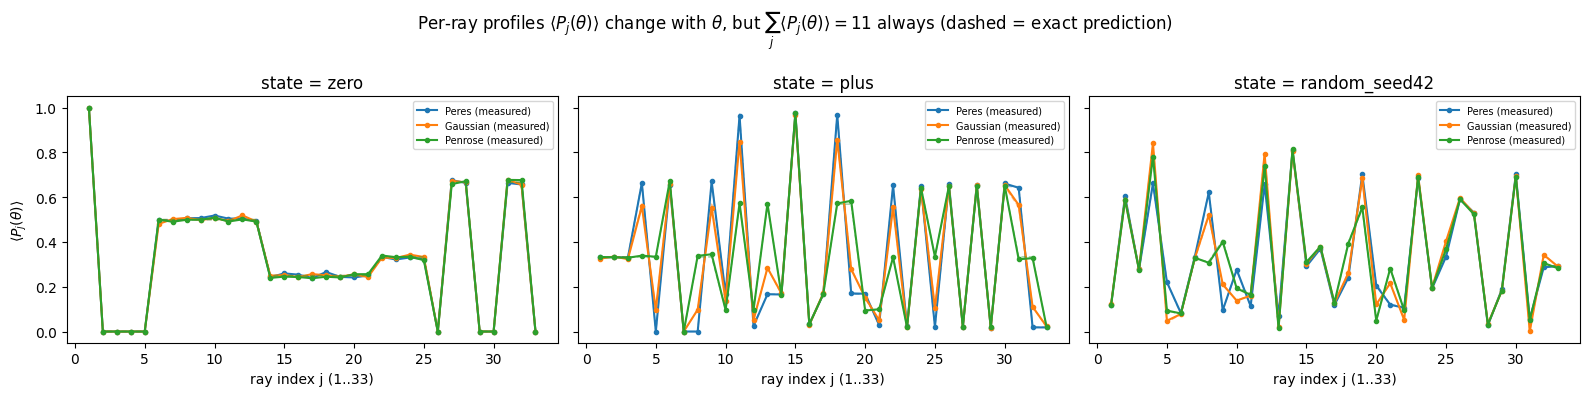


LOCAL SIMULATION: PASS. The embedded data reproduces sum_j P_j(theta)=11 on a real qiskit-aer simulator run (not just the noiseless prediction above).


In [ ]:
# =====================================================================================
# LOCAL SIMULATION -- run all 297 EXP1 circuits on qiskit-aer, shots=4000, compute the
# per-theta per-state sum_j <P_j>, assert within ~3 sigma of 11, and plot the 33 per-ray
# profiles at the 3 thetas (showing the profiles CHANGE while the sum does not).
# This cell MUST PASS headlessly (no hardware, no token).
# =====================================================================================
import matplotlib.pyplot as plt
from qiskit_aer import AerSimulator

SHOTS = 4000
sim = AerSimulator()

import time as _time

circuits = [r["circuit"] for r in EXP1_RECORDS]
t0 = _time.time()
result = sim.run(circuits, shots=SHOTS).result()
print(f"ran {len(circuits)} circuits x {SHOTS} shots on AerSimulator in {_time.time() - t0:.1f}s")

for i, r in enumerate(EXP1_RECORDS):
    counts = result.get_counts(i)
    p00 = counts.get("00", 0) / SHOTS
    r["measured_P"] = p00

# ---- per (theta, state) sums, with a binomial-sum 1-sigma estimate ----
print(f"\n{'theta':10s} {'state':16s} {'sum measured P_j':>18s} {'sigma':>10s} {'(sum-11)/sigma':>16s}")
sums_table = []
for tname in RAY_SETS:
    for sname, _ in test_states():
        recs = [r for r in EXP1_RECORDS if r["theta_name"] == tname and r["state"] == sname]
        s_meas = sum(r["measured_P"] for r in recs)
        # var(p_j_hat) = p_j(1-p_j)/SHOTS per independent circuit -> var(sum) = sum of these
        var_sum = sum(r["measured_P"] * (1 - r["measured_P"]) / SHOTS for r in recs)
        sigma = np.sqrt(var_sum)
        z = (s_meas - 11.0) / sigma if sigma > 0 else 0.0
        sums_table.append(dict(theta_name=tname, state=sname, sum_measured=s_meas, sigma=sigma, z=z))
        print(f"{tname:10s} {sname:16s} {s_meas:18.4f} {sigma:10.4f} {z:16.2f}")
        assert abs(z) < 3.5, f"{tname}/{sname}: measured sum {s_meas:.4f} is {z:.1f} sigma from 11 -- FAIL"
print("\nALL 9 (theta, state) combinations: measured sum_j <P_j(theta)> = 11 within ~3 sigma. PASS.")

# ---- plot: the 33 per-ray profiles at the 3 thetas, for the 'zero' state ----
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
colors = {"Peres": "tab:blue", "Gaussian": "tab:orange", "Penrose": "tab:green"}
for ax, sname in zip(axes, ["zero", "plus", "random_seed42"]):
    for tname in RAY_SETS:
        recs = sorted([r for r in EXP1_RECORDS if r["theta_name"] == tname and r["state"] == sname],
                       key=lambda r: r["j"])
        js = [r["j"] for r in recs]
        meas = [r["measured_P"] for r in recs]
        pred = [r["predicted_P"] for r in recs]
        ax.plot(js, meas, "o-", color=colors[tname], label=f"{tname} (measured)", markersize=3)
        ax.plot(js, pred, "--", color=colors[tname], alpha=0.5, linewidth=1)
    ax.set_title(f"state = {sname}")
    ax.set_xlabel("ray index j (1..33)")
    if sname == "zero":
        ax.set_ylabel(r"$\langle P_j(\theta)\rangle$")
    ax.legend(fontsize=7)
fig.suptitle(r"Per-ray profiles $\langle P_j(\theta)\rangle$ change with $\theta$, but "
             r"$\sum_j \langle P_j(\theta)\rangle = 11$ always (dashed = exact prediction)")
plt.tight_layout()
plt.show()

print("\nLOCAL SIMULATION: PASS. The embedded data reproduces sum_j P_j(theta)=11 on a real "
      "qiskit-aer simulator run (not just the noiseless prediction above).")


In [ ]:
# =====================================================================================
# IBM HARDWARE (guarded) -- set IBM_QUANTUM_TOKEN below to run EXP1 on a real IBM Quantum
# backend. Left EMPTY by default so the notebook runs headlessly / on the free tier without
# spending QPU time by accident.
#
# FREE-TIER BUDGETING: the free plan meters QPU *seconds*, and each Job has overhead, so we do
# NOT submit 297 separate jobs. Instead we batch the 297 circuits into 3 jobs (one per theta,
# 99 circuits each) via a single SamplerV2 session/batch -- keeping job count low is the
# single biggest lever for free-tier budget on IBM Quantum.
# =====================================================================================
# --- IBM_QUANTUM_TOKEN: read from Colab Secrets (key icon, left sidebar) ---
# Add a secret named IBM_TOKEN (your IBM Quantum API token) and enable
# "Notebook access" for this notebook. Outside Colab it falls back to the
# IBM_TOKEN environment variable, else empty (cell skips gracefully).
try:
    from google.colab import userdata
    IBM_QUANTUM_TOKEN = userdata.get("IBM_TOKEN") or ""
except Exception:
    import os
    IBM_QUANTUM_TOKEN = os.environ.get("IBM_TOKEN", "")
HW_SHOTS = 4000

if not IBM_QUANTUM_TOKEN:
    print("IBM_QUANTUM_TOKEN is empty -- skipping hardware execution (this is the default, "
          "safe, no-QPU-time-spent path). Set the token above and re-run this cell to submit "
          "real jobs.")
else:
    from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2, Batch
    from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

    service = QiskitRuntimeService(channel="ibm_quantum_platform", token=IBM_QUANTUM_TOKEN)
    backends = service.backends(operational=True, simulator=False, min_num_qubits=2)
    # prefer a Heron-family backend if available (least busy among those, else least busy overall)
    heron = [b for b in backends if "heron" in getattr(b, "processor_type", {}).get("family", "").lower()]
    pool = heron if heron else backends
    backend = service.least_busy(operational=True, simulator=False, min_num_qubits=2) \
        if not pool else min(pool, key=lambda b: b.status().pending_jobs)
    print(f"selected backend: {backend.name} (pending jobs: {backend.status().pending_jobs})")

    pm = generate_preset_pass_manager(backend=backend, optimization_level=1)

    hw_records_by_theta = {tname: [r for r in EXP1_RECORDS if r["theta_name"] == tname]
                            for tname in RAY_SETS}

    all_hw_results = {}
    with Batch(backend=backend) as batch:
        sampler = SamplerV2(mode=batch)
        jobs = {}
        for tname, recs in hw_records_by_theta.items():
            tqcs = [pm.run(r["circuit"]) for r in recs]
            jobs[tname] = sampler.run(tqcs, shots=HW_SHOTS)
            print(f"submitted job for theta={tname} ({len(tqcs)} circuits, {HW_SHOTS} shots)")

        for tname, recs in hw_records_by_theta.items():
            job_result = jobs[tname].result()
            for r, pub_result in zip(recs, job_result):
                counts = pub_result.data.c.get_counts()
                total = sum(counts.values())
                r["measured_P_hw"] = counts.get("00", 0) / total
            print(f"theta={tname}: job done.")

    print(f"\n{'theta':10s} {'state':16s} {'sum measured P_j (HW)':>22s}")
    for tname in RAY_SETS:
        for sname, _ in test_states():
            recs = [r for r in EXP1_RECORDS if r["theta_name"] == tname and r["state"] == sname]
            s_meas = sum(r["measured_P_hw"] for r in recs)
            print(f"{tname:10s} {sname:16s} {s_meas:22.4f}")
    print("\nHardware run complete. Compare the sums above to the noiseless prediction of 11 -- "
          "real-hardware deviations reflect readout/gate error, not a failure of the theorem "
          "(see the local-simulator cell above for the noiseless/shot-noise-only baseline).")


qiskit_runtime_service._discover_account:WARNING:2026-07-22 00:46:11,938: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-07-22 00:46:16,893: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: Contextuality. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.
qiskit_runtime_service.backends:WARNING:2026-07-22 00:46:16,894: Loading instance: Contextuality, plan: open


selected backend: ibm_marrakesh (pending jobs: 0)
submitted job for theta=Peres (99 circuits, 4000 shots)
submitted job for theta=Gaussian (99 circuits, 4000 shots)
submitted job for theta=Penrose (99 circuits, 4000 shots)
theta=Peres: job done.
theta=Gaussian: job done.
theta=Penrose: job done.

theta      state             sum measured P_j (HW)
Peres      zero                            11.2873
Peres      plus                            11.0340
Peres      random_seed42                   11.0965
Gaussian   zero                            11.1100
Gaussian   plus                            10.9032
Gaussian   random_seed42                   10.9857
Penrose    zero                            11.0258
Penrose    plus                            11.0320
Penrose    random_seed42                   10.9663

Hardware run complete. Compare the sums above to the noiseless prediction of 11 -- real-hardware deviations reflect readout/gate error, not a failure of the theorem (see the local-simulator c

In [ ]:
# =====================================================================================
# EXP 2 (optional) -- Hadamard-test measurement of the holonomy eigenphase phi.
# Predicted: phi/(2*pi) mod 1 = sqrt(1867)/33 mod 1 = 0.309357436...
#
# RUN_EXP2 controls whether this cell's SIMULATOR part executes at all (default True -- it is
# cheap, N=4/8 steps only, and is part of the notebook's own headless self-check).
# IBM_QUANTUM_TOKEN_EXP2 is a SEPARATE hardware guard, left EMPTY by default (off), so no real
# QPU time is spent on EXP2 unless you explicitly opt in.
# =====================================================================================
RUN_EXP2 = True
# --- IBM_QUANTUM_TOKEN_EXP2: read from Colab Secrets (key icon, left sidebar) ---
# Add a secret named IBM_TOKEN (your IBM Quantum API token) and enable
# "Notebook access" for this notebook. Outside Colab it falls back to the
# IBM_TOKEN environment variable, else empty (cell skips gracefully).
try:
    from google.colab import userdata
    IBM_QUANTUM_TOKEN_EXP2 = userdata.get("IBM_TOKEN") or ""
except Exception:
    import os
    IBM_QUANTUM_TOKEN_EXP2 = os.environ.get("IBM_TOKEN", "")

if not RUN_EXP2:
    print("RUN_EXP2 = False -- skipping Experiment 2 entirely.")
else:
    from scipy.linalg import expm

    # ---- exact connection A(theta) = A0 + A1*e^{i theta} + Am*e^{-i theta} (Cell 3 literals) ----
    def connection_A(theta):
        return A0 + A1 * np.exp(1j * theta) + Am * np.exp(-1j * theta)

    # sanity: A(theta) must be anti-Hermitian for all theta (so exp(A dtheta) is unitary)
    for th in np.linspace(0, 2 * np.pi, 7):
        Ath = connection_A(th)
        assert np.allclose(Ath + Ath.conj().T, 0, atol=1e-8), f"A({th}) not anti-Hermitian"
    print("A(theta) anti-Hermitian check passed on a 7-point grid.")

    # ---- exact eigenvector of the constant reduced generator (PHI_IDENTIFIED.md Sec.1 Step 3),
    # re-derived here from its own closed form + cross-checked against numpy.linalg.eigh ----
    M_HOLONOMY = np.array([[-43, -3, 0], [-3, 0, 3], [0, 3, 43]], dtype=float)
    PHI_TARGET = (2 * np.pi * np.sqrt(1867) / 33) % (2 * np.pi)
    PHI_TARGET_OVER_2PI = PHI_TARGET / (2 * np.pi)
    print(f"predicted phi/2pi mod 1 = sqrt(1867)/33 mod 1 = {PHI_TARGET_OVER_2PI:.9f}")

    def eigenvector_plus():
        lam = np.sqrt(1867.0)
        v_closed = np.array([1.0, -(43 + lam) / 3, (43 + lam) / (43 - lam)])
        v_closed = v_closed / np.linalg.norm(v_closed)
        w, V = np.linalg.eigh(M_HOLONOMY)
        idx = int(np.argmax(w))
        assert abs(w[idx] - lam) < 1e-9, f"eigh top eigenvalue {w[idx]} != sqrt(1867)={lam}"
        v_num = V[:, idx]
        if np.vdot(v_num, v_closed).real < 0:
            v_num = -v_num
        assert np.allclose(v_num, v_closed, atol=1e-9), "closed-form eigenvector disagrees with eigh"
        return v_closed

    psi_eig = eigenvector_plus()

    def build_step_unitaries(N):
        dtheta = 2 * np.pi / N
        return [expm(connection_A(k * dtheta) * dtheta) for k in range(N)]

    def predicted_phi(N):
        Us = build_step_unitaries(N)
        WN = np.eye(3, dtype=complex)
        for Uk in Us:
            WN = Uk @ WN
        state0 = psi_eig / np.sqrt(2)
        state1 = (WN @ psi_eig) / np.sqrt(2)
        states = [state0, state1]
        rho = np.array([[np.vdot(states[j], states[i]) for j in range(2)] for i in range(2)])
        X = np.array([[0, 1], [1, 0]], dtype=complex)
        Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
        exX = float(np.real(np.trace(rho @ X)))
        exY = float(np.real(np.trace(rho @ Y)))
        phi_meas = float(np.arctan2(exY, exX) % (2 * np.pi))
        return phi_meas, exX, exY

    Ns = (4, 8)
    for N in Ns:
        phi_meas, exX, exY = predicted_phi(N)
        print(f"  N={N}: noiseless prediction <X>={exX:+.6f} <Y>={exY:+.6f} "
              f"phi/2pi={phi_meas / (2 * np.pi):.6f}  |err vs target|={abs(phi_meas - PHI_TARGET):.3e}")

    # ---- build the actual Hadamard-test QuantumCircuits (3 qubits: 2 qutrit + 1 ancilla) ----
    def build_exp2_circuits(Ns=(4, 8)):
        S3 = complete_unitary(psi_eig.astype(complex))
        prep = unitary_block_circuit(embed_4(S3), "eig_prep")
        circuits = {}
        for N in Ns:
            Us = build_step_unitaries(N)
            for basis in ("X", "Y"):
                qc = QuantumCircuit(3, 1, name=f"exp2_N{N}_{basis}")
                qc.compose(prep, [0, 1], inplace=True)
                qc.h(2)
                for k, Uk in enumerate(Us):
                    Uk4 = embed_4(Uk)
                    cg = UnitaryGate(Uk4, label=f"U{k}").control(1)
                    qc.append(cg, [2, 0, 1])
                if basis == "X":
                    qc.h(2)
                else:
                    qc.sdg(2)
                    qc.h(2)
                qc.measure(2, 0)
                circuits[(N, basis)] = transpile(qc, basis_gates=BASIS_GATES, optimization_level=1)
        return circuits

    exp2_circuits = build_exp2_circuits(Ns)
    print(f"\nbuilt {len(exp2_circuits)} EXP2 circuits for N in {Ns} (X/Y bases)")

    # ---- SIMULATOR run (always, when RUN_EXP2=True) ----
    from qiskit_aer import AerSimulator
    sim2 = AerSimulator()
    SHOTS2 = 8000
    exp2_keys = list(exp2_circuits.keys())          # [(N,'X'), (N,'Y'), ...], fixed order
    exp2_qcs = [exp2_circuits[k] for k in exp2_keys]
    sim_result = sim2.run(exp2_qcs, shots=SHOTS2).result()
    counts_by_key = {k: sim_result.get_counts(i) for i, k in enumerate(exp2_keys)}
    print(f"\n{'N':>4s} {'<X> sim':>10s} {'<Y> sim':>10s} {'phi/2pi sim':>12s} {'|err|':>10s}")
    for N in Ns:
        cx = counts_by_key[(N, "X")]
        cy = counts_by_key[(N, "Y")]
        exX_sim = (cx.get("0", 0) - cx.get("1", 0)) / SHOTS2
        exY_sim = (cy.get("0", 0) - cy.get("1", 0)) / SHOTS2
        phi_sim = np.arctan2(exY_sim, exX_sim) % (2 * np.pi)
        err = abs(phi_sim - PHI_TARGET)
        print(f"{N:4d} {exX_sim:10.4f} {exY_sim:10.4f} {phi_sim / (2 * np.pi):12.6f} {err:10.3e}")
    print("\nEXP2 SIMULATOR run complete (this must pass headlessly; N=4/8 only -> a handful of "
          "shot-noise-limited samples of phi, not a high-precision measurement -- see the "
          "paper for the high-precision numerical/exact derivation of phi).")

    # ---- optional hardware run, separately guarded ----
    if not IBM_QUANTUM_TOKEN_EXP2:
        print("\nIBM_QUANTUM_TOKEN_EXP2 empty -- skipping EXP2 hardware execution (default).")
    else:
        from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2, Batch
        from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

        service2 = QiskitRuntimeService(channel="ibm_quantum_platform", token=IBM_QUANTUM_TOKEN_EXP2)
        backend2 = service2.least_busy(operational=True, simulator=False, min_num_qubits=3)
        print(f"selected backend for EXP2: {backend2.name}")
        pm2 = generate_preset_pass_manager(backend=backend2, optimization_level=1)
        tqcs2 = [pm2.run(qc) for qc in exp2_circuits.values()]
        with Batch(backend=backend2) as batch2:
            sampler2 = SamplerV2(mode=batch2)
            job2 = sampler2.run(tqcs2, shots=SHOTS2)
            hw_result2 = job2.result()
        keys2 = list(exp2_circuits.keys())
        hw_vals = {}
        for key, pub_result in zip(keys2, hw_result2):
            counts = pub_result.data.c.get_counts()
            total = sum(counts.values())
            hw_vals[key] = (counts.get("0", 0) - counts.get("1", 0)) / total
        print(f"\n{'N':>4s} {'<X> HW':>10s} {'<Y> HW':>10s} {'phi/2pi HW':>12s}")
        for N in Ns:
            exX_hw, exY_hw = hw_vals[(N, "X")], hw_vals[(N, "Y")]
            phi_hw = np.arctan2(exY_hw, exX_hw) % (2 * np.pi)
            print(f"{N:4d} {exX_hw:10.4f} {exY_hw:10.4f} {phi_hw / (2 * np.pi):12.6f}")


A(theta) anti-Hermitian check passed on a 7-point grid.
predicted phi/2pi mod 1 = sqrt(1867)/33 mod 1 = 0.309357436
  N=4: noiseless prediction <X>=-0.351172 <Y>=+0.931209 phi/2pi=0.307395  |err vs target|=1.233e-02
  N=8: noiseless prediction <X>=-0.361367 <Y>=+0.931293 phi/2pi=0.308910  |err vs target|=2.811e-03


qiskit_runtime_service._discover_account:WARNING:2026-07-22 01:09:28,832: Loading account with the given token. A saved account will not be used.



built 4 EXP2 circuits for N in (4, 8) (X/Y bases)

   N    <X> sim    <Y> sim  phi/2pi sim      |err|
   4    -0.3558     0.9357     0.307821  9.653e-03
   8    -0.3540     0.9295     0.307915  9.064e-03

EXP2 SIMULATOR run complete (this must pass headlessly; N=4/8 only -> a handful of shot-noise-limited samples of phi, not a high-precision measurement -- see the paper for the high-precision numerical/exact derivation of phi).


qiskit_runtime_service.__init__:WARNING:2026-07-22 01:09:32,430: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (pay-as-you-go, open), the available account instances are: Contextuality, Rigidity. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.
qiskit_runtime_service.backends:WARNING:2026-07-22 01:09:33,237: Loading instance: Contextuality, plan: open
qiskit_runtime_service.backends:WARNING:2026-07-22 01:09:34,114: Loading instance: Rigidity, plan: pay-as-you-go
qiskit_runtime_service.backends:WARNING:2026-07-22 01:09:37,247: Using instance: Contextuality, plan: open


selected backend for EXP2: ibm_marrakesh


KeyboardInterrupt: 

## How to read the output, and what to report back

**Cell 3 (embedded data):** confirms the pasted ray/connection literals are byte-identical
(mod 12-decimal rounding) to the extraction-time SHA256, and that the noiseless tight-frame
identity $\sum_j |v_j\rangle\langle v_j| = 11 I_3$ holds at all three $\theta$ points. If this
cell fails, **stop** — the embedded data itself is corrupted and nothing downstream is
meaningful.

**Cell 5 (local simulation, must always pass):** reports, for each of the 9 $(\theta, \text{state})$
combinations, the measured $\sum_j \langle P_j(\theta)\rangle$ over 4000 shots per circuit and how
many standard deviations it is from 11. It also plots the 33 per-ray profiles
$\langle P_j(\theta)\rangle$ at the three $\theta$ values — visually, the curves are *very
different* across the three panels/colors (that's the KS family flexing), while every curve's
area — the sum over $j$ — lands at 11 regardless.

**Cell 6 (hardware, opt-in):** if you supplied a real IBM Quantum token, this reports the same
sums measured on physical qubits. Real hardware has gate/readout error, so expect the sums to
sit somewhat off 11 (typically by a few percent on current NISQ devices) — the interesting
number to report is *how close* the hardware sum gets, and whether all 9 sums move together
(consistent with a state/theta-independent systematic bias) rather than looking randomly
scattered (which would suggest a bug rather than device noise).

**Cell 7 (EXP2, optional):** reports $\phi/2\pi \bmod 1$ estimated from a Hadamard test at
$N=4,8$ discretization steps, to compare against the exact target $0.309357436\ldots$. With only
4–8 steps and finite shots this is a rough estimate, not a precision test — it is included to
demonstrate the circuit construction and give a sanity-checkable number, not to claim a
high-precision experimental confirmation of $\phi$.

**What to report back after running this notebook:**
1. The **Cell 3 checksum status** (OK / mismatch).
2. The **9-row sum table** from Cell 5 (theta, state, measured sum, sigma, z-score) — this is
   the headline simulator result.
3. If hardware was run: the backend name, the **9-row hardware sum table** from Cell 6, and
   qualitatively how far off 11 the hardware sums land.
4. If EXP2 was run: the $\phi/2\pi$ estimates at $N=4,8$ (simulator, and hardware if run).

**References.**
- M. Flores Gordillo, *Exact rigidity certificates for Kochen–Specker sets, the graded flex
  dictionary, and the Peres–Penrose circle*, Preprints.org 224406 (2026).
- E. Gould and P. K. Aravind, *Isomorphism between the Peres and Penrose proofs of the BKS
  theorem in three dimensions*, Found. Phys. **40**, 1096 (2010), arXiv:0909.4502.
